Модель разграничения доступа для ИС автоматизации пункта проката
RBAC + Mandatory Access Control + ACL

📊 Результаты проверки доступа:
   User            Resource Operation  Granted Security Level User Clearance
  alice rental_contract_001      READ     True   CONFIDENTIAL   CONFIDENTIAL
  alice rental_contract_001    DELETE     True   CONFIDENTIAL   CONFIDENTIAL
    bob rental_contract_001     WRITE    False   CONFIDENTIAL       INTERNAL
    bob rental_contract_001    DELETE    False   CONFIDENTIAL       INTERNAL
charlie rental_contract_001      READ    False   CONFIDENTIAL         PUBLIC
charlie   public_price_list      READ     True         PUBLIC         PUBLIC
charlie   public_price_list     WRITE    False         PUBLIC         PUBLIC
    bob      item_inventory     WRITE    False       INTERNAL       INTERNAL

📁 Лог доступа (последние 5 записей):
  ('bob', 'rental_contract_001', 'DELETE', False, 'RBAC')
  ('charlie', 'rental_contract_001', 'READ', False, 'Mandatory')
  ('charlie

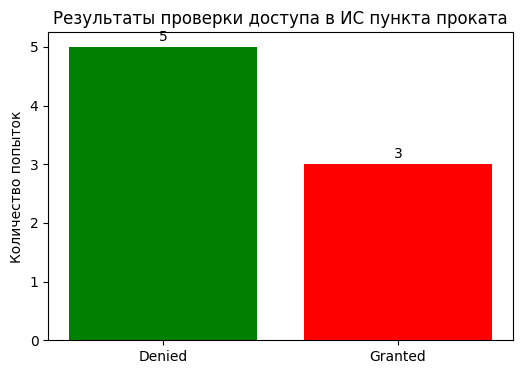


✅ Вывод: комбинированная модель (роли + мандатный + ACL) эффективна
для пункта проката, защищая конфиденциальные договоры и инвентарь.


In [1]:
# -*- coding: utf-8 -*-
"""
Задание 6Ф. Механизмы разграничения доступа в ИС пункта проката.
Реализация RBAC + мандатный контроль + ACL.
Воспроизводимо в Google Colab.
"""

import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Set, Optional
from enum import Enum
import logging

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ------------------- 1. Модели безопасности -------------------

class SecurityLevel(Enum):
    """Уровни мандатного контроля (от низкого к высокому)."""
    PUBLIC = 1      # открытая информация
    INTERNAL = 2    # внутренняя
    CONFIDENTIAL = 3 # конфиденциальная

class Operation(Enum):
    """Типы операций."""
    READ = "read"
    WRITE = "write"
    DELETE = "delete"
    CREATE = "create"

@dataclass
class Role:
    """Роль с правами на операции (RBAC)."""
    name: str
    permissions: Set[Operation] = field(default_factory=set)

@dataclass
class User:
    """Пользователь системы."""
    username: str
    role: Role
    clearance: SecurityLevel  # уровень допуска (мандатный)

@dataclass
class Resource:
    """Ресурс (документ, товар, договор)."""
    id: str
    owner: str
    acl: Dict[str, Set[Operation]]  # Access Control List: user -> операции
    mandatory_level: SecurityLevel  # гриф секретности

# ------------------- 2. Механизм принятия решений -------------------

class AccessMediator:
    """Посредник, проверяющий все правила доступа."""

    def __init__(self):
        self.access_log = []  # для статистики

    def check_access(self, user: User, resource: Resource, op: Operation) -> bool:
        """
        Проверка комбинированного доступа:
        1. RBAC: есть ли у роли право на операцию?
        2. Мандатный: clearance >= resource.mandatory_level для чтения,
                     clearance == resource.mandatory_level для записи.
        3. ACL: если ресурс имеет ACL, то проверяется явное разрешение.
        """
        # Правило 1: RBAC
        if op not in user.role.permissions:
            logger.warning(f"ДОСТУП ОТКАЗАН (RBAC): {user.username} -> {op} на {resource.id}")
            self.access_log.append((user.username, resource.id, op.name, False, "RBAC"))
            return False

        # Правило 2: Мандатный контроль (Bell-LaPadula simplified)
        if op == Operation.READ:
            if user.clearance.value < resource.mandatory_level.value:
                logger.warning(f"ДОСТУП ОТКАЗАН (Mandatory): {user.username} читает {resource.id} (уровень {resource.mandatory_level.name})")
                self.access_log.append((user.username, resource.id, op.name, False, "Mandatory"))
                return False
        elif op in (Operation.WRITE, Operation.DELETE):
            if user.clearance.value != resource.mandatory_level.value:
                logger.warning(f"ДОСТУП ОТКАЗАН (Mandatory write): {user.username} -> {op.name} на {resource.id}")
                self.access_log.append((user.username, resource.id, op.name, False, "Mandatory"))
                return False

        # Правило 3: ACL (если есть запись для пользователя или владелец)
        if user.username in resource.acl:
            if op in resource.acl[user.username]:
                logger.info(f"ДОСТУП РАЗРЕШЕН (ACL): {user.username} -> {op.name} на {resource.id}")
                self.access_log.append((user.username, resource.id, op.name, True, "ACL"))
                return True
        elif user.username == resource.owner:
            logger.info(f"ДОСТУП РАЗРЕШЕН (владелец): {user.username} -> {op.name} на {resource.id}")
            self.access_log.append((user.username, resource.id, op.name, True, "Owner"))
            return True

        # Если нет правил в ACL и не владелец
        logger.warning(f"ДОСТУП ОТКАЗАН (нет прав ACL): {user.username} -> {op.name} на {resource.id}")
        self.access_log.append((user.username, resource.id, op.name, False, "ACL missing"))
        return False

# ------------------- 3. Эмуляция работы пункта проката -------------------

def run_rental_simulation():
    """Эмуляция операций в ИС пункта проката с проверкой доступа."""

    # Создаём роли
    admin_role = Role("admin", {Operation.READ, Operation.WRITE, Operation.DELETE, Operation.CREATE})
    manager_role = Role("manager", {Operation.READ, Operation.WRITE, Operation.CREATE})
    client_role = Role("client", {Operation.READ, Operation.CREATE})

    # Создаём пользователей
    users = {
        "alice": User("alice", admin_role, SecurityLevel.CONFIDENTIAL),
        "bob": User("bob", manager_role, SecurityLevel.INTERNAL),
        "charlie": User("charlie", client_role, SecurityLevel.PUBLIC)
    }

    # Ресурсы с разными уровнями секретности и ACL
    resources = {
        "rental_contract_001": Resource(
            id="rental_contract_001",
            owner="alice",
            acl={"bob": {Operation.READ, Operation.WRITE}},
            mandatory_level=SecurityLevel.CONFIDENTIAL
        ),
        "item_inventory": Resource(
            id="item_inventory",
            owner="alice",
            acl={"bob": {Operation.READ}, "charlie": {Operation.READ}},
            mandatory_level=SecurityLevel.INTERNAL
        ),
        "public_price_list": Resource(
            id="public_price_list",
            owner="alice",
            acl={"charlie": {Operation.READ}},
            mandatory_level=SecurityLevel.PUBLIC
        )
    }

    mediator = AccessMediator()

    # Сценарий проверки
    test_scenarios = [
        (users["alice"], resources["rental_contract_001"], Operation.READ),   # владелец + высокий уровень
        (users["alice"], resources["rental_contract_001"], Operation.DELETE), # владелец
        (users["bob"], resources["rental_contract_001"], Operation.WRITE),    # есть в ACL
        (users["bob"], resources["rental_contract_001"], Operation.DELETE),   # нет в ACL
        (users["charlie"], resources["rental_contract_001"], Operation.READ),  # недостаточно прав
        (users["charlie"], resources["public_price_list"], Operation.READ),    # разрешено
        (users["charlie"], resources["public_price_list"], Operation.WRITE),   # запрещено по RBAC
        (users["bob"], resources["item_inventory"], Operation.WRITE),          # запрещено по ACL
    ]

    results = []
    for user, res, op in test_scenarios:
        granted = mediator.check_access(user, res, op)
        results.append({
            "User": user.username,
            "Resource": res.id,
            "Operation": op.name,
            "Granted": granted,
            "Security Level": res.mandatory_level.name,
            "User Clearance": user.clearance.name
        })

    return pd.DataFrame(results), mediator.access_log

# ------------------- 4. Визуализация и вывод -------------------

def plot_access_results(df):
    """График: разрешённые и запрещённые доступы."""
    counts = df["Granted"].value_counts()
    plt.figure(figsize=(6,4))
    plt.bar(counts.index.map({True: "Granted", False: "Denied"}), counts.values, color=["green", "red"])
    plt.title("Результаты проверки доступа в ИС пункта проката")
    plt.ylabel("Количество попыток")
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.1, str(v), ha='center')
    plt.show()

def main():
    print("="*60)
    print("Модель разграничения доступа для ИС автоматизации пункта проката")
    print("RBAC + Mandatory Access Control + ACL")
    print("="*60)

    df, log = run_rental_simulation()

    print("\n📊 Результаты проверки доступа:")
    print(df.to_string(index=False))

    print("\n📁 Лог доступа (последние 5 записей):")
    for entry in log[-5:]:
        print(f"  {entry}")

    plot_access_results(df)

    print("\n✅ Вывод: комбинированная модель (роли + мандатный + ACL) эффективна")
    print("для пункта проката, защищая конфиденциальные договоры и инвентарь.")

if __name__ == "__main__":
    main()